# Hypothesis Testing Using Real Social/Education Data

## Purpose and scope

These notes use a real student-performance dataset to frame hypothesis testing as a research workflow rather than a collection of isolated formulas. Each test is tied to a question, a null hypothesis, an alternative hypothesis, an effect size, and an interpretation caution.

Main concepts covered:

- null and alternative hypotheses;
- p-value and significance level;
- t-test and Mann-Whitney U test;
- chi-square test and Cramer's V;
- ANOVA, Kruskal-Wallis, and eta-squared;
- Pearson and Spearman correlation;
- multiple-comparison correction;
- statistical significance versus practical significance.

## Prerequisites

Assumed background: pandas, descriptive statistics, and basic group comparison. The notebook briefly introduces each test before implementation.

In [ ]:
# Optional installation cell. Uncomment if any package is missing in your environment.
# !pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn ucimlrepo openml

## Problem statement

Educational datasets are often used to ask questions such as:

- Do students with internet access perform differently?
- Are study-time groups associated with final grades?
- Are absences correlated with final grade?
- Are support programs associated with pass/fail status?

These questions sound simple, but they require careful statistical thinking. A small p-value does not prove a large or causal effect. We need assumptions, effect size, and context.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 4)

from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import zipfile
import io
import requests

## Dataset description and source

Dataset: **UCI Student Performance dataset**, loaded directly from the UCI Machine Learning Repository zip URL.

The dataset contains student demographic, social, and school-related attributes. We will use the Portuguese language dataset (`student-por.csv`) because it has more records than the math dataset. The final grade `G3` is used as the outcome variable.

Key variables include:

- `G1`, `G2`, `G3`: first period, second period, and final grades;
- `studytime`: weekly study time category;
- `failures`: number of past class failures;
- `absences`: number of school absences;
- `internet`: internet access at home;
- `schoolsup`: extra educational support;
- `higher`: desire to pursue higher education;
- `Medu`, `Fedu`: mother/father education level.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'

response = requests.get(url)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print('Files in zip:', z.namelist())
    with z.open('student-por.csv') as f:
        df = pd.read_csv(f, sep=';')

print('Shape:', df.shape)
display(df.head())

Files in zip: ['student-mat.csv', 'student-por.csv', 'student-merge.R', 'student.txt']
Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


## Initial data quality and variable overview

Before testing hypotheses, inspect missing values, data types, and basic summaries. Statistical tests assume that variables are correctly coded.

In [3]:
display(df.info())
missing = df.isna().sum().to_frame('missing_count')
missing['missing_percent'] = 100 * missing['missing_count'] / len(df)
display(missing[missing['missing_count'] > 0])

display(df[['G1', 'G2', 'G3', 'studytime', 'failures', 'absences', 'Medu', 'Fedu']].describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

None

,missing_count,missing_percent


,count,mean,std,min,25%,50%,75%,max
G1,649.0,11.3991,2.7453,0.0,10.0,11.0,13.0,19.0
G2,649.0,11.5701,2.9136,0.0,10.0,11.0,13.0,19.0
G3,649.0,11.9060,3.2307,0.0,10.0,12.0,14.0,19.0
studytime,649.0,1.9307,0.8295,1.0,1.0,2.0,2.0,4.0
failures,649.0,0.2219,0.5932,0.0,0.0,0.0,0.0,3.0
absences,649.0,3.6595,4.6408,0.0,0.0,2.0,6.0,32.0
Medu,649.0,2.5146,1.1346,0.0,2.0,2.0,4.0,4.0
Fedu,649.0,2.3066,1.0999,0.0,1.0,2.0,3.0,4.0


## Exploratory data analysis

EDA is not optional. It helps us understand distributions, outliers, and group sizes before applying tests. A test result without EDA can be misleading.

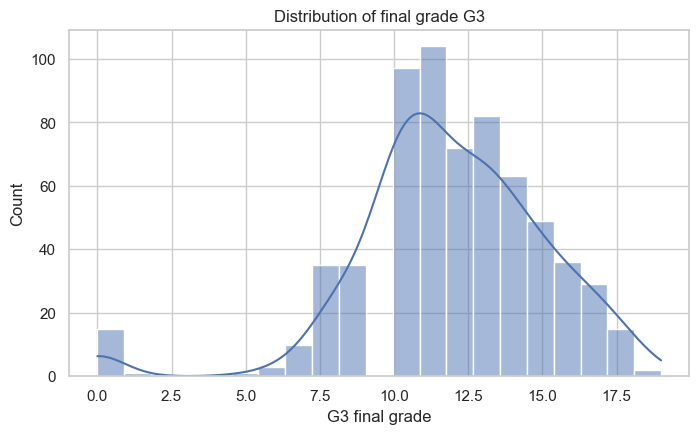

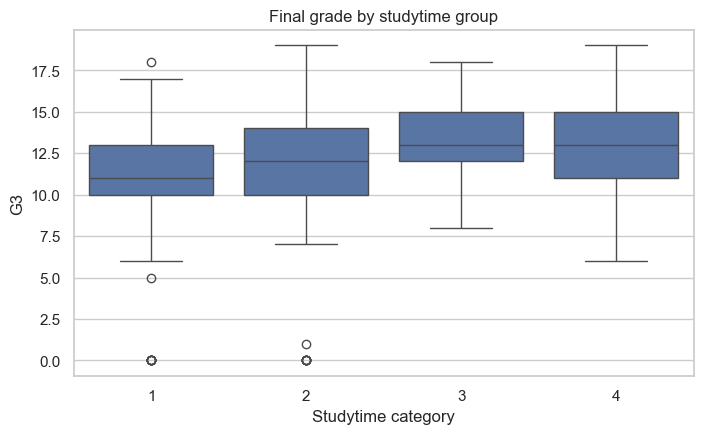

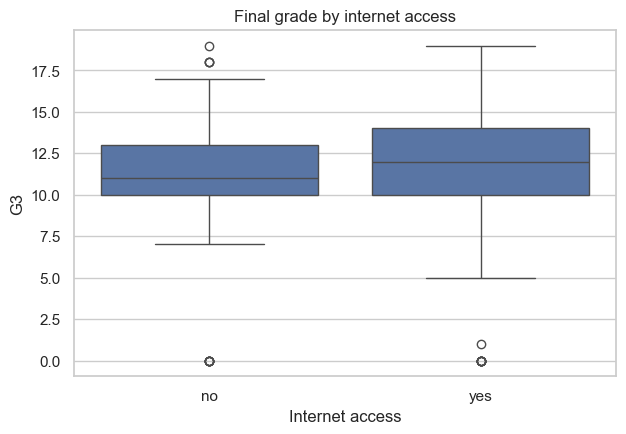

In [4]:
plt.figure(figsize=(8, 4.5))
sns.histplot(df['G3'], bins=21, kde=True)
plt.title('Distribution of final grade G3')
plt.xlabel('G3 final grade')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='studytime', y='G3')
plt.title('Final grade by studytime group')
plt.xlabel('Studytime category')
plt.ylabel('G3')
plt.show()

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x='internet', y='G3')
plt.title('Final grade by internet access')
plt.xlabel('Internet access')
plt.ylabel('G3')
plt.show()

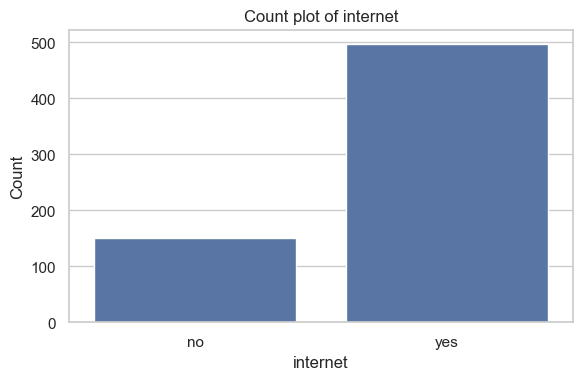

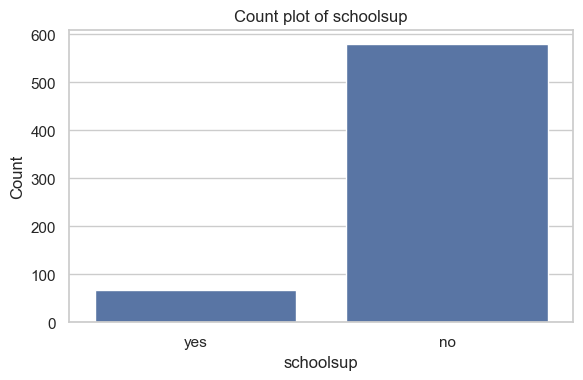

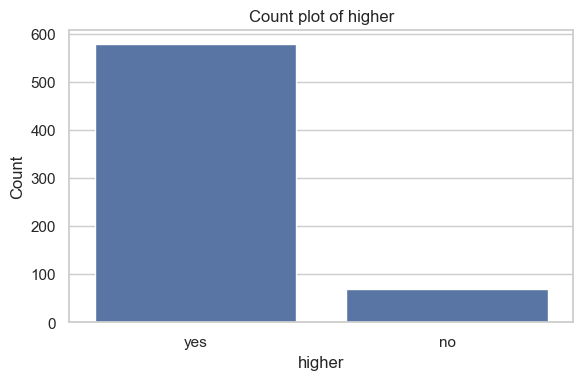

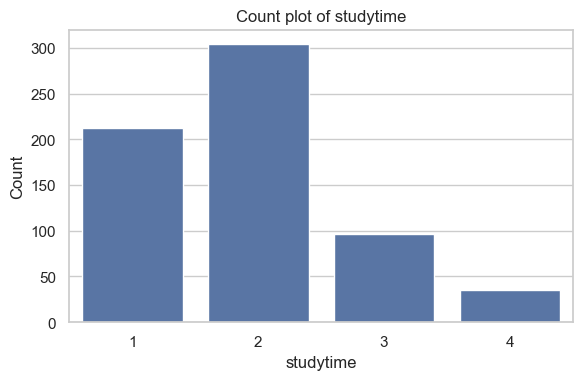

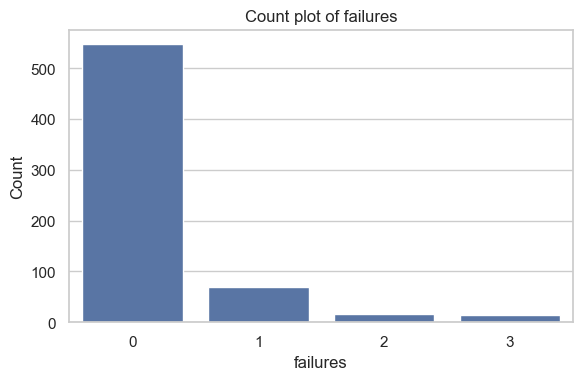

In [5]:
cat_cols = ['internet', 'schoolsup', 'higher', 'studytime', 'failures']
for col in cat_cols:
    plt.figure(figsize=(6.5, 3.8))
    sns.countplot(data=df, x=col)
    plt.title(f'Count plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Correlation heatmap for numerical variables

Correlation provides a first look at linear association. It does not imply causation.

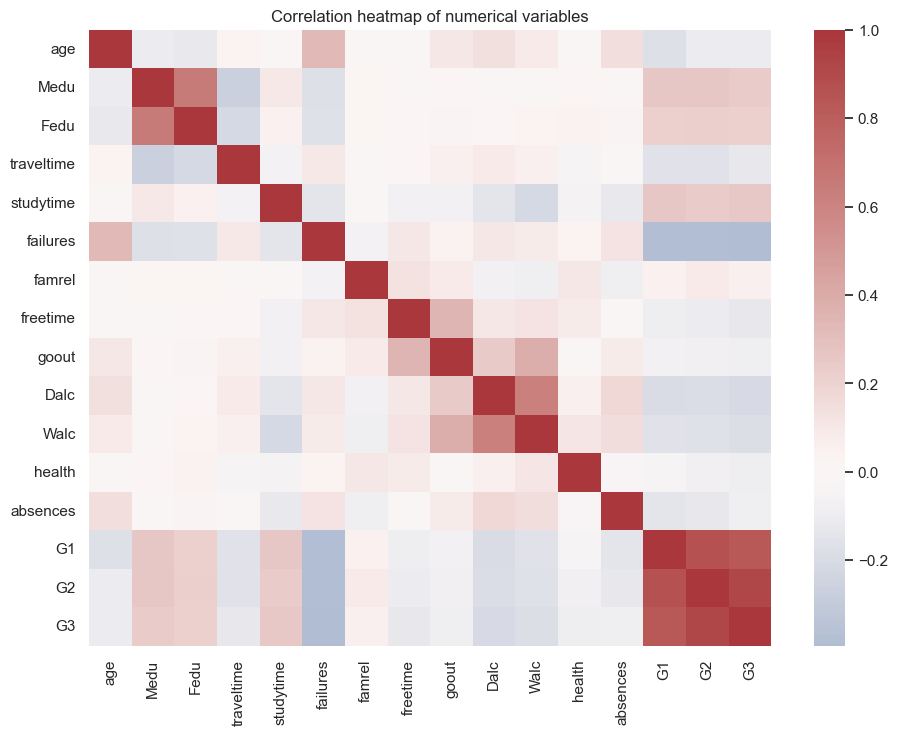

In [6]:
num_cols = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(11, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap='vlag', center=0, annot=False)
plt.title('Correlation heatmap of numerical variables')
plt.show()

## Compact concept note

A hypothesis test evaluates how compatible the observed data is with a null hypothesis. The p-value is not the probability that the null hypothesis is true; it is the probability of obtaining results at least as extreme as the observed result, assuming the null hypothesis and test assumptions are correct.

Because p-values are affected by sample size, they should be reported with effect sizes. Effect size answers a different question: how large or meaningful is the observed difference or association?

## Helper functions for effect sizes

P-values indicate compatibility with a null hypothesis. Effect sizes indicate practical magnitude. We will report both.

In [7]:
def cohens_d(x, y):
    x, y = np.asarray(x), np.asarray(y)
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd

def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

def eta_squared_anova(groups):
    all_values = np.concatenate([np.asarray(g) for g in groups])
    grand_mean = all_values.mean()
    ss_between = sum(len(g) * (np.asarray(g).mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum((all_values - grand_mean) ** 2)
    return ss_between / ss_total

## Assumption checks used as diagnostics

Parametric tests such as t-tests and ANOVA are most appropriate when observations are independent, group distributions are not extremely irregular, and variance assumptions are reasonable. These checks do not automatically decide the analysis, but they explain why non-parametric alternatives are also included.

In [8]:
diagnostic_rows = []
for group_name, values in [
    ('internet=yes', df.loc[df['internet'] == 'yes', 'G3']),
    ('internet=no', df.loc[df['internet'] == 'no', 'G3'])
]:
    values = pd.Series(values).dropna()
    sample_for_shapiro = values.sample(min(len(values), 5000), random_state=RANDOM_STATE) if len(values) > 5000 else values
    sh_stat, sh_p = stats.shapiro(sample_for_shapiro)
    diagnostic_rows.append({
        'group': group_name,
        'n': len(values),
        'mean': values.mean(),
        'median': values.median(),
        'std': values.std(ddof=1),
        'shapiro_p_value': sh_p
    })

assumption_diagnostics = pd.DataFrame(diagnostic_rows)
display(assumption_diagnostics)

levene_stat, levene_p = stats.levene(
    df.loc[df['internet'] == 'yes', 'G3'].dropna(),
    df.loc[df['internet'] == 'no', 'G3'].dropna(),
    center='median'
)
print(f"Levene test for internet groups: statistic={levene_stat:.4f}, p-value={levene_p:.6f}")

,group,n,mean,median,std,shapiro_p_value
0,internet=yes,498,12.1727,12.0,3.1171,1.6014e-13
1,internet=no,151,11.0265,11.0,3.4466,1.9264e-09


Levene test for internet groups: statistic=0.0913, p-value=0.762611


## 1. One-sample t-test

Research question: Is the mean final grade significantly different from a chosen reference value?

We choose 10 as a reference because grades are on a 0-20 scale and 10 is often a natural midpoint/pass-like threshold. In a real study, the reference value must be justified before looking at the data.

- Null hypothesis H0: mean G3 = 10.
- Alternative hypothesis H1: mean G3 is not equal to 10.

In [9]:
reference_value = 10
sample = df['G3'].dropna()
t_stat, p_value = stats.ttest_1samp(sample, popmean=reference_value)

result = pd.Series({
    'reference_value': reference_value,
    'sample_mean': sample.mean(),
    't_statistic': t_stat,
    'p_value': p_value,
    'mean_difference': sample.mean() - reference_value
})
display(result.to_frame('one_sample_t_test'))

,one_sample_t_test
reference_value,1.0000e+01
sample_mean,1.1906e+01
t_statistic,1.5030e+01
p_value,5.0677e-44
mean_difference,1.9060e+00


### Interpretation guide

If the p-value is small, the sample mean is statistically different from the reference value. Also inspect the mean difference. A difference can be statistically significant but educationally small.

## 2. Independent two-sample t-test: internet access and final grade

Research question: Do students with internet access have different final grades than students without internet access?

- H0: mean G3 is the same for both groups.
- H1: mean G3 differs between groups.

We use Welch's t-test because it does not require equal variances.

In [10]:
g_yes = df.loc[df['internet'] == 'yes', 'G3'].dropna()
g_no = df.loc[df['internet'] == 'no', 'G3'].dropna()

t_stat, p_value = stats.ttest_ind(g_yes, g_no, equal_var=False)
d = cohens_d(g_yes, g_no)

display(pd.DataFrame({
    'group': ['internet=yes', 'internet=no'],
    'n': [len(g_yes), len(g_no)],
    'mean_G3': [g_yes.mean(), g_no.mean()],
    'std_G3': [g_yes.std(ddof=1), g_no.std(ddof=1)]
}))

print(f"Welch t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Cohen's d (yes - no): {d:.4f}")

,group,n,mean_G3,std_G3
0,internet=yes,498,12.1727,3.1171
1,internet=no,151,11.0265,3.4466


Welch t-statistic: 3.6580
p-value: 0.000315
Cohen's d (yes - no): 0.3586


### Interpretation guide

Cohen's d helps judge practical magnitude. Rough informal thresholds are 0.2 small, 0.5 medium, and 0.8 large, but context matters. A small p-value with a tiny d may not be practically important.

## 3. Mann-Whitney U test: non-parametric alternative

The Mann-Whitney U test is useful when the t-test assumptions are questionable, such as strong non-normality or ordinal-like outcomes. It tests whether values from one group tend to be larger than values from another group, not exactly whether means differ.

In [11]:
u_stat, mw_p = stats.mannwhitneyu(g_yes, g_no, alternative='two-sided')
print(f'Mann-Whitney U statistic: {u_stat:.4f}')
print(f'p-value: {mw_p:.6f}')

Mann-Whitney U statistic: 45616.5000
p-value: 0.000064


### Interpretation guide

Compare the Mann-Whitney result with the t-test result. Agreement strengthens the evidence for a group difference. Disagreement suggests that distribution shape, outliers, or variance differences may matter.

## 4. Chi-square test of association

Research question: Is internet access associated with desire for higher education?

Both variables are categorical, so we use a contingency table and chi-square test.

- H0: internet access and higher-education aspiration are independent.
- H1: they are associated.

We also report Cramer's V as an effect size.

In [12]:
contingency = pd.crosstab(df['internet'], df['higher'])
display(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
cv = cramers_v(contingency)

print(f'Chi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'p-value: {p:.6f}')
print(f"Cramer's V: {cv:.4f}")
print('Expected frequencies under independence:')
display(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

higher,no,yes
internet,,
no,22,129
yes,47,451


Chi-square statistic: 2.6941
Degrees of freedom: 1
p-value: 0.100719
Cramer's V: 0.0644
Expected frequencies under independence:


higher,no,yes
internet,,
no,16.0539,134.9461
yes,52.9461,445.0539


### Interpretation guide

The p-value tells whether the association is statistically detectable. Cramer's V tells whether the association is weak or strong. Always check expected counts; very small expected counts can make chi-square approximations unreliable.

## 5. ANOVA: final grades across studytime groups

Research question: Do final grades differ across studytime categories?

- H0: all studytime groups have the same mean G3.
- H1: at least one group mean differs.

ANOVA compares between-group variation to within-group variation.

In [13]:
study_groups = [group['G3'].dropna().values for _, group in df.groupby('studytime')]
labels = sorted(df['studytime'].unique())

f_stat, anova_p = stats.f_oneway(*study_groups)
eta2 = eta_squared_anova(study_groups)

study_summary = df.groupby('studytime')['G3'].agg(['count', 'mean', 'std', 'median'])
display(study_summary)
print(f'ANOVA F-statistic: {f_stat:.4f}')
print(f'p-value: {anova_p:.6f}')
print(f'eta-squared: {eta2:.4f}')

,count,mean,std,median
studytime,,,,
1,212,10.8443,3.2186,11.0
2,305,12.0918,3.2431,12.0
3,97,13.2268,2.5021,13.0
4,35,13.0571,3.0384,13.0


ANOVA F-statistic: 15.8763
p-value: 0.000000
eta-squared: 0.0688


### Interpretation guide

ANOVA tells whether any group differs, but not which pair differs. Eta-squared estimates the proportion of outcome variation explained by studytime group. A statistically significant ANOVA can still have a small eta-squared.

## 6. Kruskal-Wallis test: non-parametric alternative to ANOVA

Kruskal-Wallis compares group distributions using ranks. It is useful when ANOVA assumptions are questionable.

In [14]:
h_stat, kw_p = stats.kruskal(*study_groups)
print(f'Kruskal-Wallis H statistic: {h_stat:.4f}')
print(f'p-value: {kw_p:.6f}')

Kruskal-Wallis H statistic: 50.3162
p-value: 0.000000


## 7. Correlation tests

Research question: Are absences or previous grades correlated with final grade?

Pearson correlation measures linear association. Spearman correlation measures monotonic association using ranks and is less sensitive to non-normality and outliers.

In [15]:
for feature in ['absences', 'G1', 'G2', 'failures', 'studytime']:
    pearson_r, pearson_p = stats.pearsonr(df[feature], df['G3'])
    spearman_r, spearman_p = stats.spearmanr(df[feature], df['G3'])
    print(f'Feature: {feature}')
    print(f'  Pearson r={pearson_r:.4f}, p={pearson_p:.6f}')
    print(f'  Spearman rho={spearman_r:.4f}, p={spearman_p:.6f}')

Feature: absences
  Pearson r=-0.0914, p=0.019896
  Spearman rho=-0.1585, p=0.000050
Feature: G1
  Pearson r=0.8264, p=0.000000
  Spearman rho=0.8833, p=0.000000
Feature: G2
  Pearson r=0.9185, p=0.000000
  Spearman rho=0.9445, p=0.000000
Feature: failures
  Pearson r=-0.3933, p=0.000000
  Spearman rho=-0.4484, p=0.000000
Feature: studytime
  Pearson r=0.2498, p=0.000000
  Spearman rho=0.2747, p=0.000000


### Interpretation guide

Previous grades often correlate strongly with final grade because they measure related academic performance over time. Absences may show weaker or non-linear relationships. Correlation does not prove that changing one variable will cause a change in the other.

## 8. Multiple comparisons

If ANOVA suggests differences across studytime groups, we may compare pairs. But multiple tests increase the chance of false positives. We will apply Holm correction to pairwise Mann-Whitney tests.

In [16]:
pair_rows = []
for a, b in combinations(sorted(df['studytime'].unique()), 2):
    x_a = df.loc[df['studytime'] == a, 'G3']
    x_b = df.loc[df['studytime'] == b, 'G3']
    stat, p_raw = stats.mannwhitneyu(x_a, x_b, alternative='two-sided')
    pair_rows.append({'group_1': a, 'group_2': b, 'raw_p_value': p_raw})

pair_df = pd.DataFrame(pair_rows)
reject, p_corrected, _, _ = multipletests(pair_df['raw_p_value'], alpha=0.05, method='holm')
pair_df['holm_corrected_p_value'] = p_corrected
pair_df['reject_after_holm'] = reject
display(pair_df)

,group_1,group_2,raw_p_value,holm_corrected_p_value,reject_after_holm
0,1,2,1.7818e-06,8.9090e-06,True
1,1,3,1.0276e-10,6.1654e-10,True
2,1,4,2.9303e-04,1.1721e-03,True
3,2,3,1.5621e-03,4.6863e-03,True
4,2,4,1.7372e-01,3.4745e-01,False
5,3,4,5.4543e-01,5.4543e-01,False


### Interpretation guide

Some raw p-values may appear significant before correction but not after correction. This is expected: correction protects against false positives when many tests are performed.

## Output-grounded analytical summary

The next cell collects the major results into one table. It helps separate statistical evidence from effect magnitude and prevents the final interpretation from depending only on p-values.

In [17]:
internet_t_stat, internet_p = stats.ttest_ind(g_yes, g_no, equal_var=False)
internet_d = cohens_d(g_yes, g_no)
chi2_stat, chi2_p, _, _ = stats.chi2_contingency(contingency)

summary_tests = pd.DataFrame([
    {
        'analysis': 'One-sample final grade vs reference',
        'test': 'one-sample t-test',
        'p_value': stats.ttest_1samp(sample, popmean=reference_value).pvalue,
        'effect_size_or_difference': sample.mean() - reference_value,
        'effect_type': 'mean difference'
    },
    {
        'analysis': 'Final grade by internet access',
        'test': "Welch's t-test",
        'p_value': internet_p,
        'effect_size_or_difference': internet_d,
        'effect_type': "Cohen's d"
    },
    {
        'analysis': 'Internet access vs higher-education aspiration',
        'test': 'chi-square',
        'p_value': chi2_p,
        'effect_size_or_difference': cv,
        'effect_type': "Cramer's V"
    },
    {
        'analysis': 'Final grade across studytime groups',
        'test': 'ANOVA',
        'p_value': anova_p,
        'effect_size_or_difference': eta2,
        'effect_type': 'eta-squared'
    },
    {
        'analysis': 'Final grade across studytime groups',
        'test': 'Kruskal-Wallis',
        'p_value': kw_p,
        'effect_size_or_difference': np.nan,
        'effect_type': 'rank-based test'
    }
])

summary_tests['statistically_significant_at_0.05'] = summary_tests['p_value'] < 0.05
display(summary_tests)

,analysis,test,p_value,effect_size_or_difference,effect_type,statistically_significant_at_0.05
0,One-sample final grade vs reference,one-sample t-test,5.0677e-44,1.9060,mean difference,True
1,Final grade by internet access,Welch's t-test,3.1533e-04,0.3586,Cohen's d,True
2,Internet access vs higher-education aspiration,chi-square,1.0072e-01,0.0644,Cramer's V,False
3,Final grade across studytime groups,ANOVA,5.7057e-10,0.0688,eta-squared,True
4,Final grade across studytime groups,Kruskal-Wallis,6.8416e-11,NaN,rank-based test,True


## Limitations

- The dataset is observational, so associations should not be interpreted as causal effects.
- Some variables are ordinal categories; treating them as numeric can be convenient but imperfect.
- Test assumptions may be partly violated, especially for bounded grades and unequal group sizes.
- Effect-size interpretation requires educational context, not only generic thresholds.
- Unmeasured variables such as teacher effects, school context, and family background may confound associations.

## What we learned

- A useful hypothesis test starts with a clear research question and a justified null hypothesis.
- P-values and effect sizes answer different questions and should be interpreted together.
- Parametric and non-parametric tests can agree or disagree because they emphasize different aspects of the data.
- Multiple pairwise tests require correction to control false-positive risk.
- Statistical association in social or education data is not automatically causal.

## Possible extensions

- Fit multiple linear regression for G3 and compare single-factor conclusions with adjusted effects.
- Compare math and Portuguese datasets after checking overlap and consistency.
- Add permutation tests for assumption-light inference.
- Use causal diagrams to identify possible confounders before interpreting effects.